In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf

tf.get_logger().setLevel("FATAL")


In [2]:
import catppuccin
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow import keras
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [3]:
matplotlib.style.use(["dark_background", catppuccin.PALETTE.mocha.identifier])
%matplotlib inline

In [4]:
df = pd.read_csv("./datasets/telco_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.drop(columns=["customerID"], inplace=True)

In [11]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [12]:
print(f"{'Column':<20}{'Null Count':^10}\n")
for col in df.columns:
    print(f"{col:<20} {df[col].isnull().sum():^10}")

Column              Null Count

gender                   0     
SeniorCitizen            0     
Partner                  0     
Dependents               0     
tenure                   0     
PhoneService             0     
MultipleLines            0     
InternetService          0     
OnlineSecurity           0     
OnlineBackup             0     
DeviceProtection         0     
TechSupport              0     
StreamingTV              0     
StreamingMovies          0     
Contract                 0     
PaperlessBilling         0     
PaymentMethod            0     
MonthlyCharges           0     
TotalCharges             0     
Churn                    0     


In [13]:
print(f"{'Column':<20}{'Values':^10}\n")
for col in df.select_dtypes(include=["object"]).columns:
    print(f"{col:<20} {df[col].unique()}")

Column                Values  

gender               ['Female' 'Male']
Partner              ['Yes' 'No']
Dependents           ['No' 'Yes']
PhoneService         ['No' 'Yes']
MultipleLines        ['No phone service' 'No' 'Yes']
InternetService      ['DSL' 'Fiber optic' 'No']
OnlineSecurity       ['No' 'Yes' 'No internet service']
OnlineBackup         ['Yes' 'No' 'No internet service']
DeviceProtection     ['No' 'Yes' 'No internet service']
TechSupport          ['No' 'Yes' 'No internet service']
StreamingTV          ['No' 'Yes' 'No internet service']
StreamingMovies      ['No' 'Yes' 'No internet service']
Contract             ['Month-to-month' 'One year' 'Two year']
PaperlessBilling     ['Yes' 'No']
PaymentMethod        ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges         ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn                ['No' 'Yes']


In [14]:
df["gender"] = df["gender"].map({"Female": 0, "Male": 1}).astype(int)
df["InternetService"] = df["InternetService"].map(
    {"DSL": "dsl", "Fiber optic": "fiber_optic", "No": "no"}
)
df["Contract"] = (
    df["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2}).astype(int)
)
df["PaymentMethod"] = df["PaymentMethod"].map(
    {
        "Electronic check": "electronic_checkMailed",
        "Mailed check": "mailed_check",
        "Bank transfer (automatic)": "bank_transfer",
        "Credit card (automatic)": "credit_card",
    }
)

df.replace("No phone service", "No", inplace=True)
df.replace("No internet service", "No", inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0).astype(float)

In [15]:
for col in [
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "Churn",
]:
    df[col] = df[col].map({"No": 0, "Yes": 1}).astype(int)

In [16]:
cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]
len(cols)


16

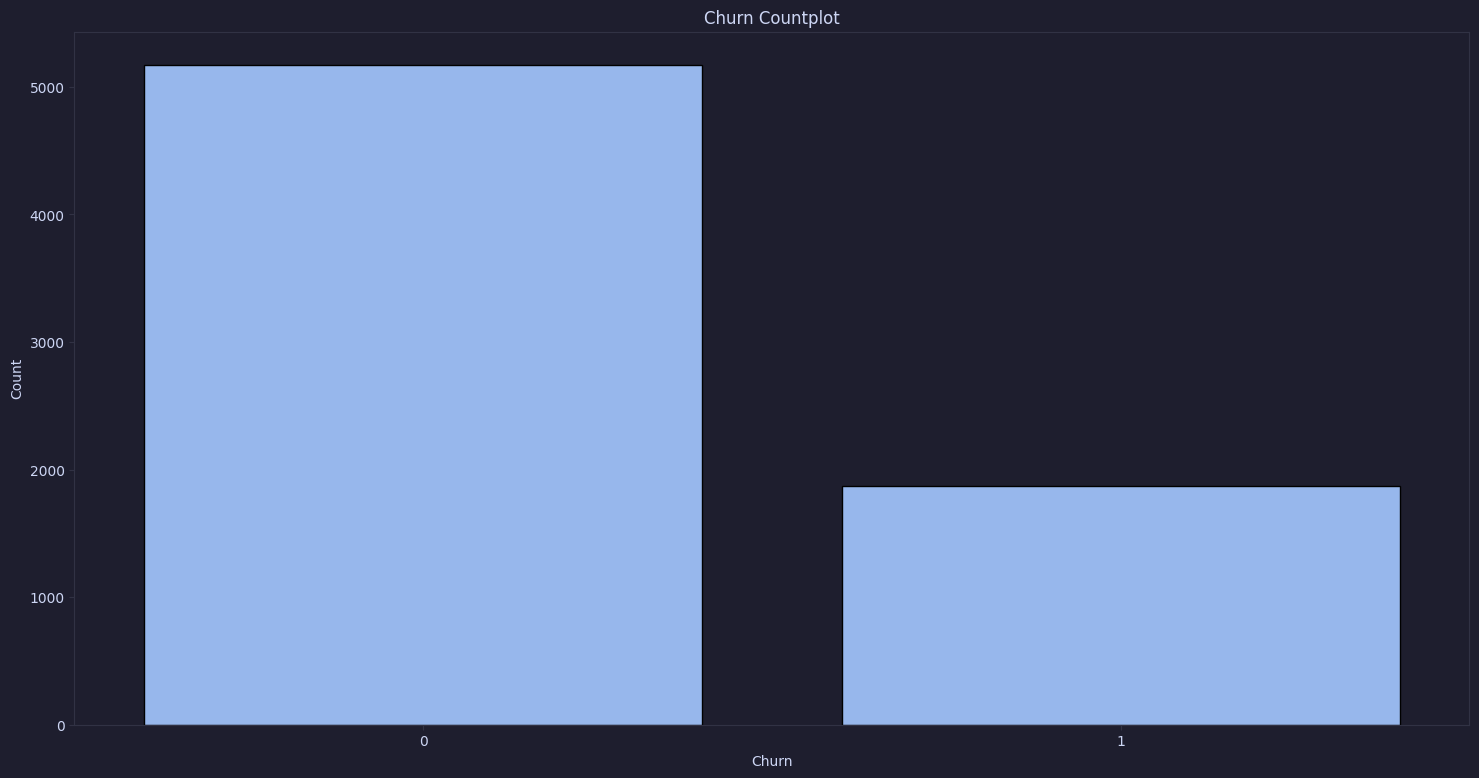

In [17]:
plt.figure(figsize=(18, 9))

sns.countplot(data=df, x="Churn", edgecolor="black", fill=True)
plt.title("Churn Countplot")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


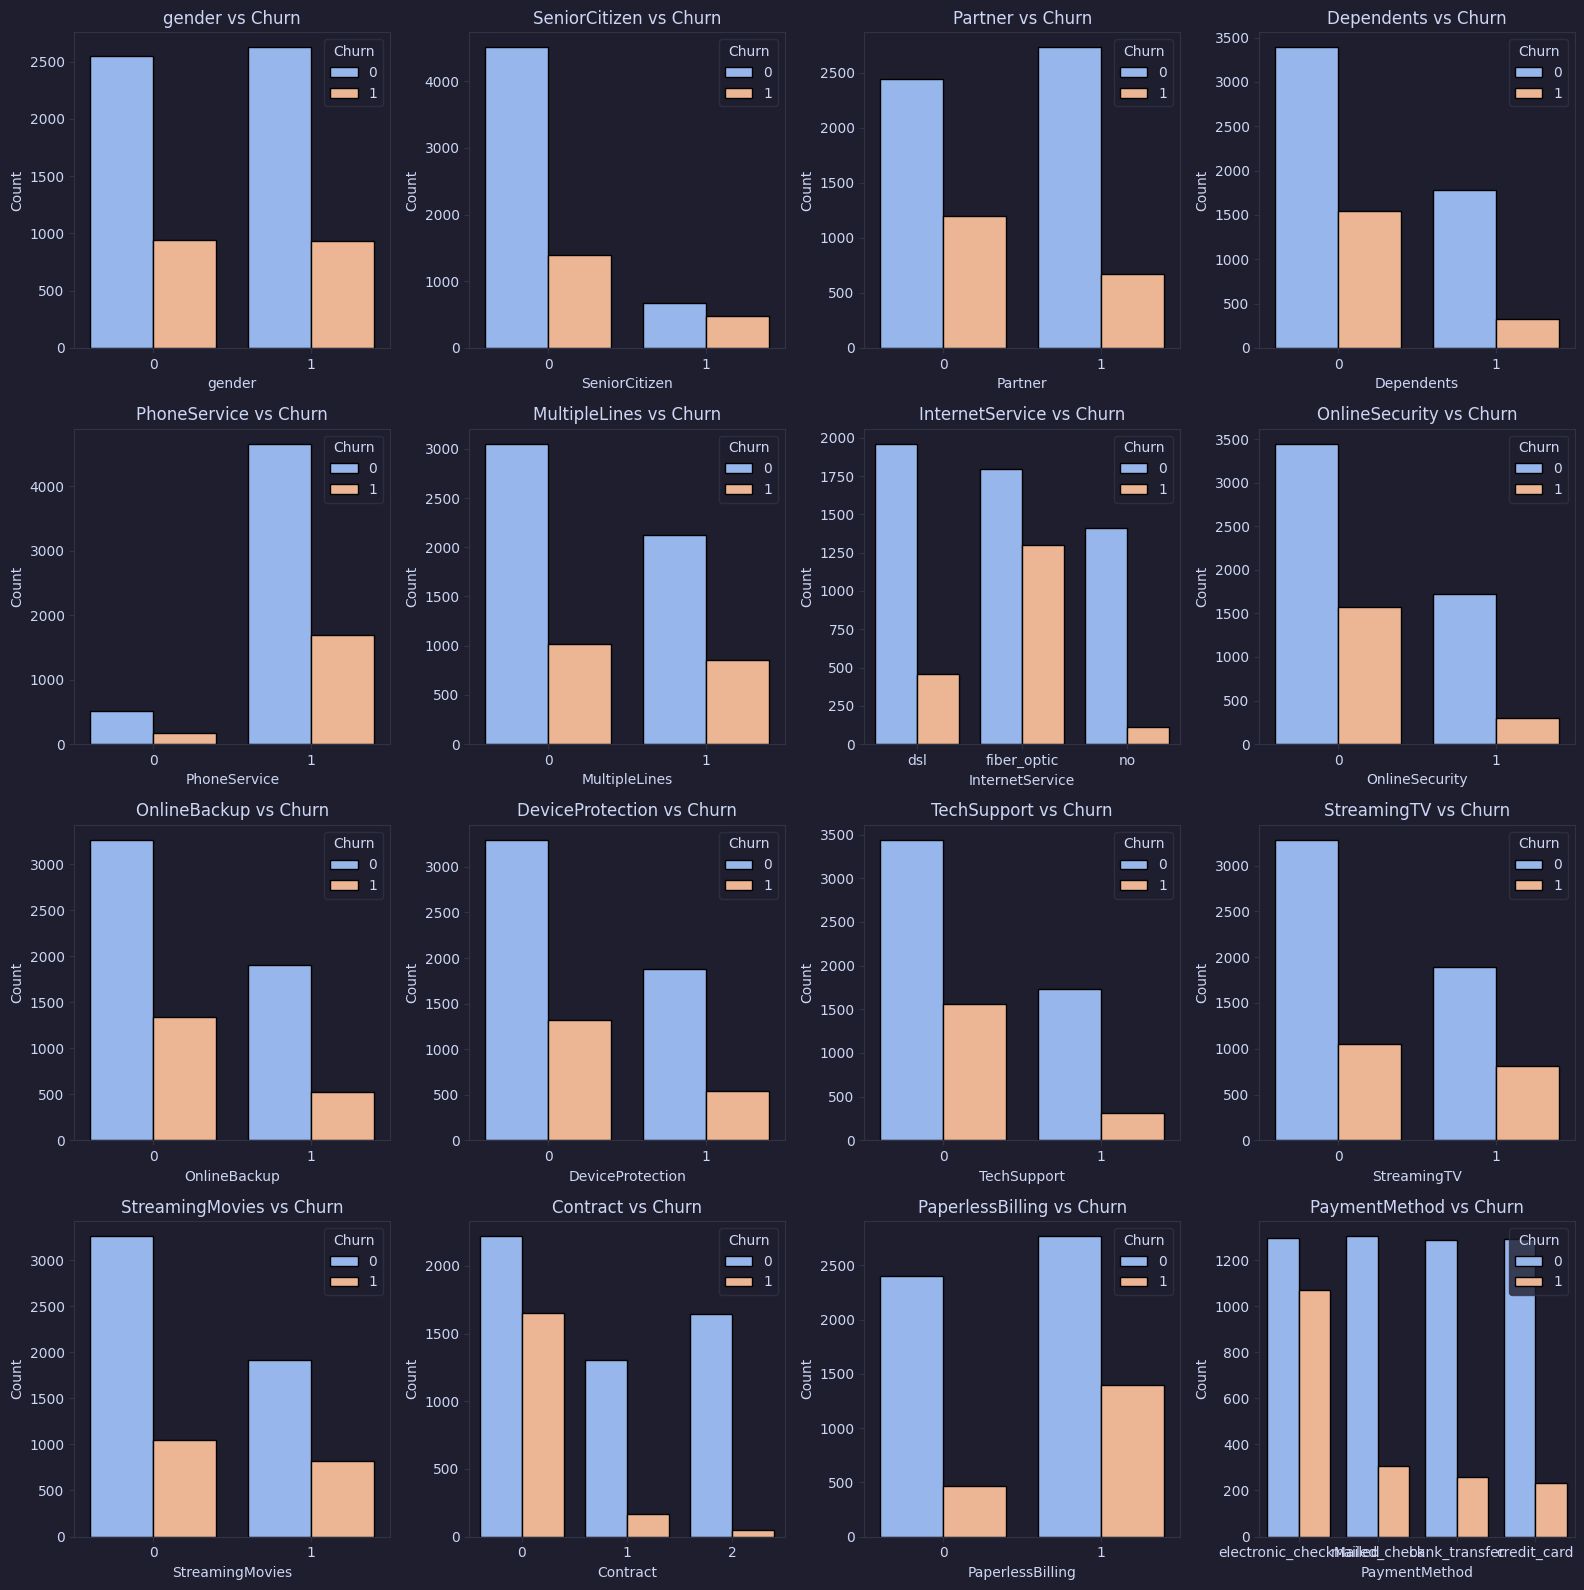

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.countplot(data=df, x=col, hue="Churn", edgecolor="black", ax=ax)
    ax.set_title(f"{col} vs Churn")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(title="Churn")

plt.tight_layout()
plt.show()

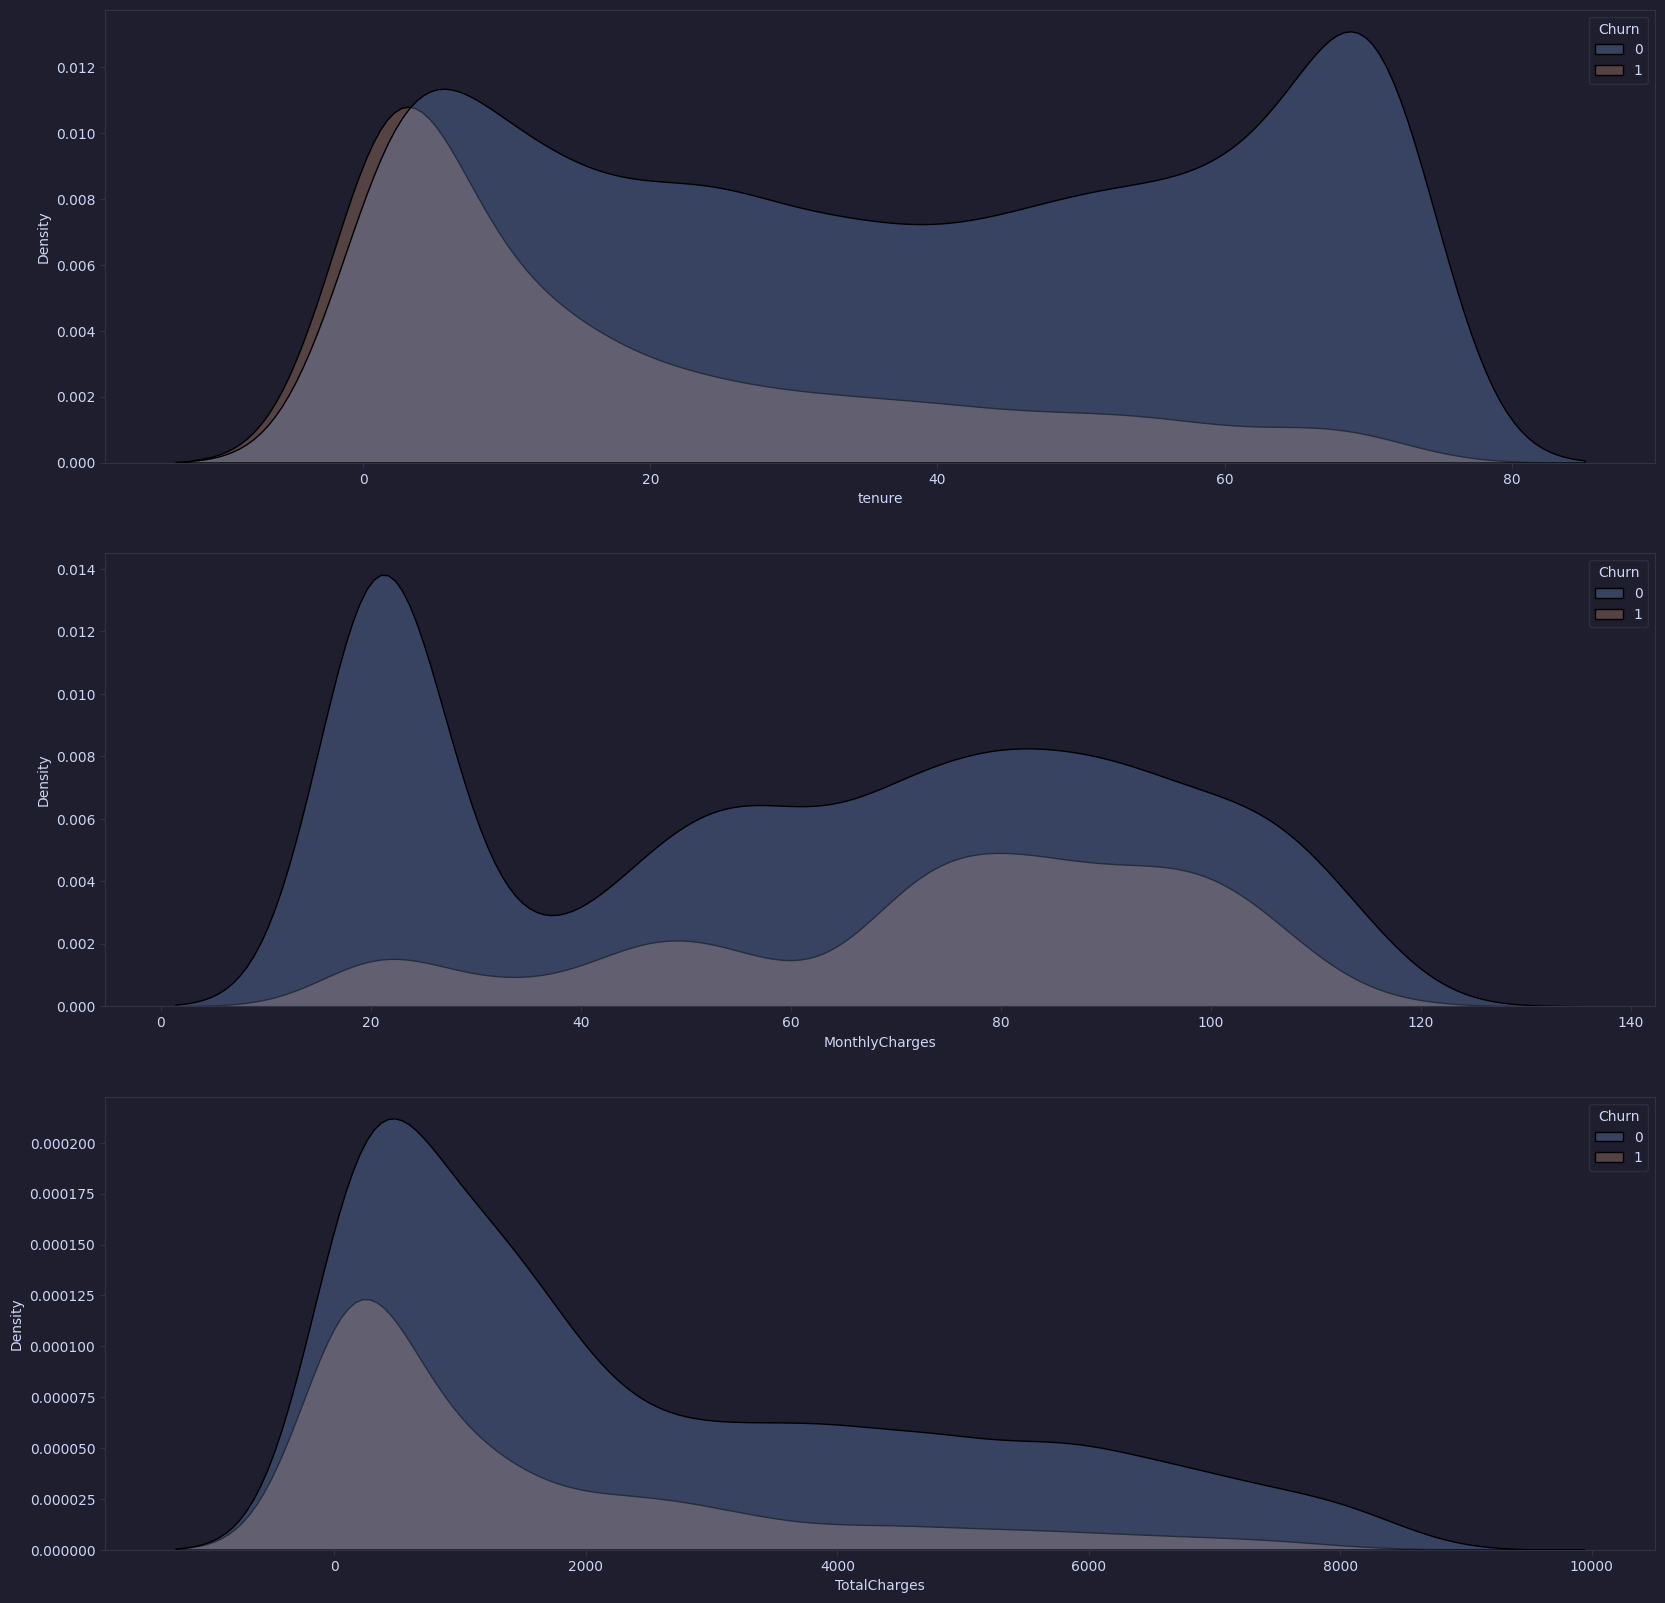

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(20, 20))
axes = axes.flatten()
kde_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
for ax, col in zip(axes, kde_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", edgecolor="black", fill=True, ax=ax)


In [20]:
df_ = pd.get_dummies(df, columns=["InternetService", "PaymentMethod"], dtype=int)
df = pd.concat([df_.drop(columns=["Churn"]), df_["Churn"]], axis=1)
df


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,InternetService_dsl,InternetService_fiber_optic,InternetService_no,PaymentMethod_bank_transfer,PaymentMethod_credit_card,PaymentMethod_electronic_checkMailed,PaymentMethod_mailed_check,Churn
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,1,0,0,0,0,1,0,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,1,0,0,0,0,0,1,0
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,1,1
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,1,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,1,0,0,0,0,0,1,0
7039,0,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,1,0,0,1,0,0,0
7040,0,0,1,1,11,0,0,1,0,0,...,29.60,346.45,1,0,0,0,0,1,0,0
7041,1,1,1,0,4,1,1,0,0,0,...,74.40,306.60,0,1,0,0,0,0,1,1


In [21]:
from sklearn.preprocessing import MinMaxScaler

X = df.drop(columns=["Churn"])
y = df["Churn"]

In [22]:
smoten = SMOTE(sampling_strategy="minority", random_state=42)

print(f"Before resampling: {Counter(y)}")
X, y = smoten.fit_resample(X, y)
print(f"After resampling: {Counter(y)}")

Before resampling: Counter({0: 5174, 1: 1869})
After resampling: Counter({0: 5174, 1: 5174})


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [51]:
model = keras.Sequential(
    [
        keras.Input(shape=(X_train.shape[1],)),
        keras.layers.Flatten(),
        keras.layers.Dense(1000, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(500, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

In [52]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1000)           │        25,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 576,621 (2.20 MB)

 Trainable params: 576,621 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.fit(X_train, y_train, epochs=10)


Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7536 - auc: 0.8258 - loss: 0.6202
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7568 - auc: 0.8311 - loss: 0.7770
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7762 - auc: 0.8502 - loss: 0.6089
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8016 - auc: 0.8828 - loss: 0.4497
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8141 - auc: 0.8961 - loss: 0.4139
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8195 - auc: 0.8981 - loss: 0.4102
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8102 - auc: 0.8898 - loss: 0.4297
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8113 - auc: 0.8908 - loss: 0.4292
Epoch 9/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7966 - auc: 0.8728 - loss: 0.5072
Epoch 10/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8056 - auc: 0.8860 - lo

In [54]:
model.evaluate(X_test, y_test)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8101 - auc: 0.9103 - loss: 0.3981


[0.39811429381370544, 0.8101449012756348, 0.910256028175354]

In [55]:
y_hat = model.predict(X_test)
y_hat = [0 if y < 0.5 else 1 for y in y_hat]

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


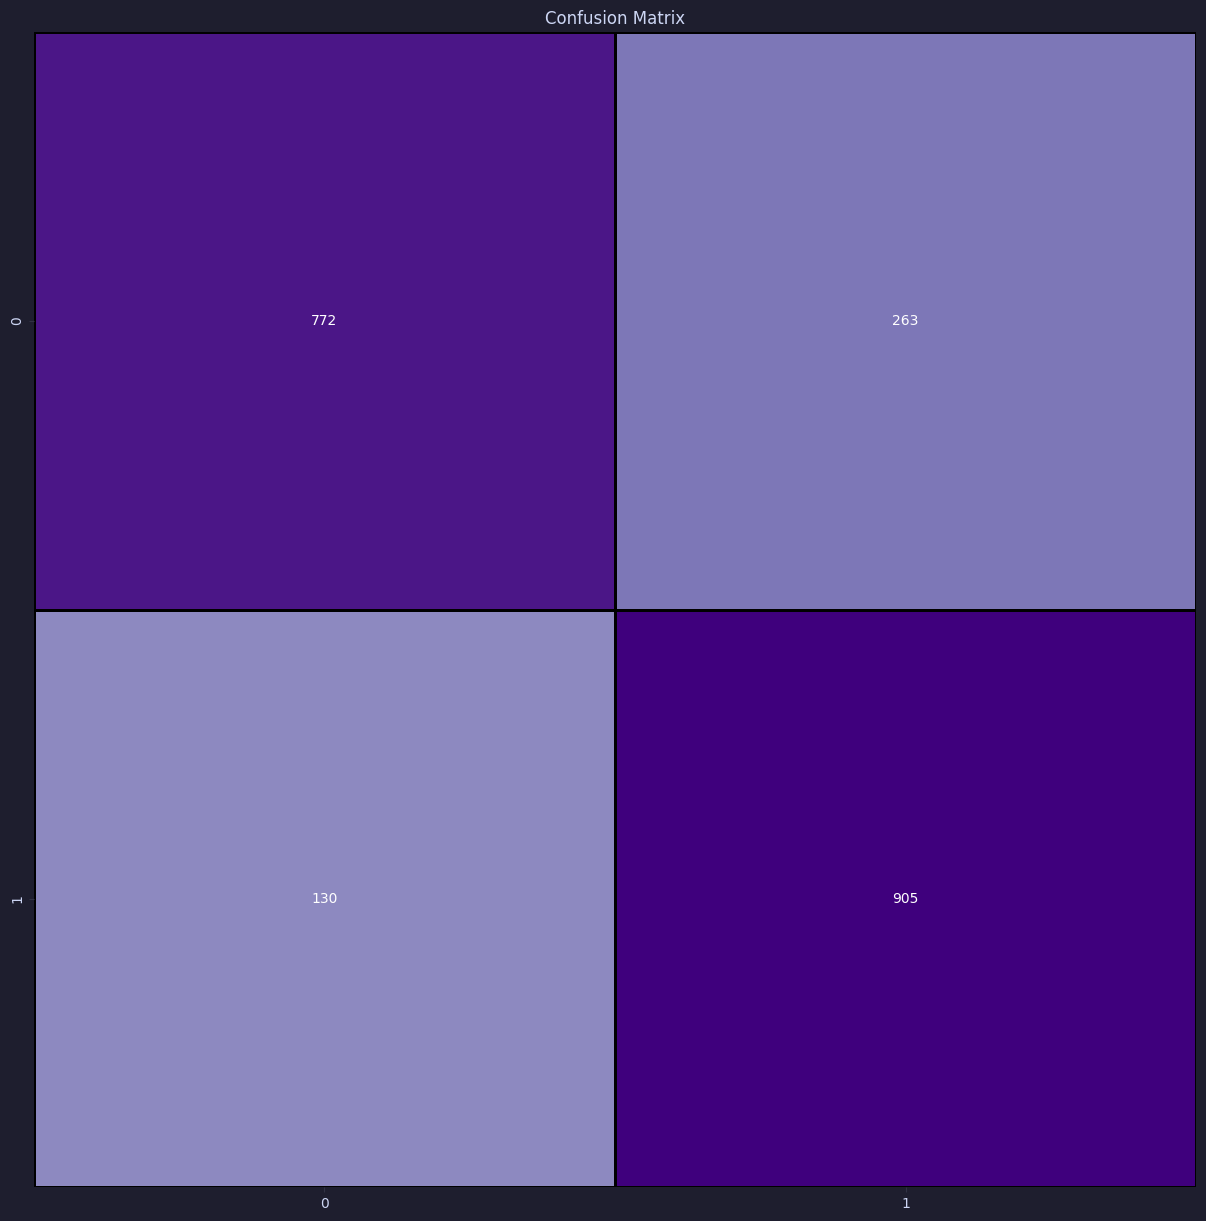

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_hat)
plt.figure(figsize=(15, 15))

sns.heatmap(
    data=cm,
    edgecolor="black",
    cbar=False,
    fmt="d",
    annot=True,
    linecolor="black",
    linewidths=2,
    center=0,
    cmap="Purples",
)
plt.title("Confusion Matrix")
plt.show()

In [57]:
model.export("./telco_model")

Saved artifact at './telco_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  5659639504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660986528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660988992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660986880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660988816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660987936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660987232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660988640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660987760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5660991808: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Lite Model without Quantization

In [58]:
denominator = 1024
converter = tf.lite.TFLiteConverter.from_saved_model("./telco_model")
tflite_model = converter.convert()

print(f"TFLite(Quant) model size {np.round(len(tflite_model) / denominator, 2)} KB")

TFLite(Quant) model size 2255.2 KB


W0000 00:00:1769441039.517752 1807538 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1769441039.517772 1807538 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.


In [59]:
converter = tf.lite.TFLiteConverter.from_saved_model("./telco_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

print(
    f"TFLite(Quant) model size {np.round(len(tflite_quant_model) / denominator, 2)} KB"
)

TFLite(Quant) model size 573.7 KB


W0000 00:00:1769441039.653837 1807538 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1769441039.653849 1807538 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
